In [1]:
from simfile import SimFile
from simulation import Simulation
from validation import switchOffAllEffects, fitGaussian2D
import os
import matplotlib.pyplot as plt
import referenceFrames as rf
import numpy as np
from scipy import constants
import math
import h5py
import platophot as phot

In [2]:
sim = Simulation("JitterSmoothing")
switchOffAllEffects(sim)
sim.outputDir = os.environ["PLATO_WORKDIR"]
workDir = os.environ["PLATO_WORKDIR"]

sim["ObservingParameters/NumExposures"] = 1
dim = 9
sim["SubField/NumRows"] = dim
sim["SubField/NumColumns"] = dim

# One full-frame exposure

sim["CCD/IncludeConvolution"] = "no"
sim["PSF/Model"] = "MappedGaussian"

ccdCode = '2'
sim["CCD/Position"] = ccdCode

pixelSize = sim["CCD/PixelSize"] * constants.micro / constants.milli

ra, dec = rf.pixelToSkyCoordinates(sim, ccdCode, (dim) / 2, (dim) / 2)

ra = math.degrees(ra)
dec = math.degrees(dec)

starCatalogFilename = os.environ["PLATO_WORKDIR"] + "generatedFromPixelCoordinates.starcat"
sim["ObservingParameters/StarCatalogFile"] = starCatalogFilename

myFile = open(starCatalogFilename, "w")
myFile.write("# RA DEC Vmag starID\n")
myFile.write("{0}  {1}  {2}  {3}\n".format(ra, dec, 12.5, 1))
myFile.close()

sim["ControlHDF5Content/WriteSubPixelImages"] = True

In [3]:
sim["CCD/IncludeConvolution"] = "yes"
sim["PSF/Model"] = "MappedGaussian"

# Size of the source

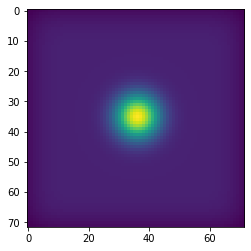

In [4]:
imageWithoutJS = sim.run(removeOutputFile = True).getSubPixelImage(0)
plt.imshow(imageWithoutJS)

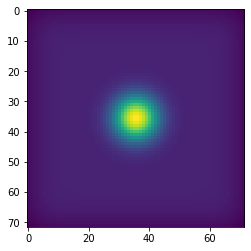

In [9]:
sim["PSF/MappedGaussian/IncludeJitterSmoothing"] = "yes"
imageWithJS = sim.run(removeOutputFile = True).getSubPixelImage(0)
plt.imshow(imageWithJS)

In [11]:
dim = dim * sim["SubField/SubPixels"]
sigma = sim["PSF/MappedGaussian/Sigma"]
params = fitGaussian2D(imageWithoutJS, np.max(imageWithoutJS), dim / 2, dim / 2, sigma, sigma, subtractConstant = True)
print("Sigma:", params[3])
print("vs.", sigma)

Sigma: 0.639
vs. 0.639


In [13]:
sigma = math.sqrt(math.pow(sim["PSF/MappedGaussian/Sigma"], 2) + math.pow(0.5 / sim["SubField/SubPixels"], 2))
params = fitGaussian2D(imageWithoutJS, np.max(imageWithoutJS), dim / 2, dim / 2, sigma, sigma, subtractConstant = True)
print("Sigma:", params[3])
print("vs.", sigma)

Sigma: 0.6420492582349114
vs. 0.6420492582349114


# Photometry

In [14]:
dim = 21

sim["SubField/NumRows"] = dim
sim["SubField/NumColumns"] = dim

ra, dec = rf.pixelToSkyCoordinates(sim, ccdCode, (dim) / 2, (dim) / 2)

ra = math.degrees(ra)
dec = math.degrees(dec)

sim["ObservingParameters/StarCatalogFile"] = starCatalogFilename

myFile = open(starCatalogFilename, "w")
myFile.write("# RA DEC Vmag starID\n")
myFile.write("{0}  {1}  {2}  {3}\n".format(ra, dec, 12.5, 1))
myFile.close()

sim["ControlHDF5Content/WriteSubPixelImages"] = False

numExposures = 5000
sim["ObservingParameters/NumExposures"] = numExposures

sim["Platform/UseJitter"] = True
sim["Platform/UseJitterFromFile"] = True
sim["Platform/JitterPitchRms"] = 0
sim["Platform/JitterRollRms"] = 0

sim["PSF/MappedGaussian/IncludeJitterSmoothing"] = "no"

output = sim.run(removeOutputFile = True)

In [15]:
outputFile = h5py.File(workDir + "JitterSmoothing.hdf5")
starIDsInImage0, row, col, Xmm, Ymm, flux = output.getStarCoordinates(0)

print("Start")
phot.photometry(workDir + "JitterSmoothing.hdf5", "photometryOutputWithoutJS.hdf5", starIDsInImage0, maxNexposures=numExposures)
print("Done")

Start
0 5000
Looping over all images in HDF5 file.
Image # 0
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
Number of targets:  1
[1]
[1]
Image # 1
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
Number of targets:  1
[1]
[1]
Image # 2
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
Number of targets:  1
[1]
[1]
Image # 3
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
Number of targets:  1
[1]
[1]
Image # 4
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.0250250

Number of targets:  1
[1]
[1]
Image # 50
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
Number of targets:  1
[1]
[1]
Image # 51
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
Number of targets:  1
[1]
[1]
Image # 52
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
Number of targets:  1
[1]
[1]
Image # 53
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
Number of targets:  1
[1]
[1]
Image # 54
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU


Number of targets:  1
[1]
[1]
Image # 102
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
Number of targets:  1
[1]
[1]
Image # 103
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
Number of targets:  1
[1]
[1]
Image # 104
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
Number of targets:  1
[1]
[1]
Image # 105
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
Number of targets:  1
[1]
[1]
Image # 106
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-

Number of targets:  1
[1]
[1]
Image # 156
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
Number of targets:  1
[1]
[1]
Image # 157
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
Number of targets:  1
[1]
[1]
Image # 158
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
Number of targets:  1
[1]
[1]
Image # 159
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
Number of targets:  1
[1]
[1]
Image # 160
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-

Number of targets:  1
[1]
[1]
Image # 209
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
Number of targets:  1
[1]
[1]
Image # 210
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
Number of targets:  1
[1]
[1]
Image # 211
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
Number of targets:  1
[1]
[1]
Image # 212
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
Number of targets:  1
[1]
[1]
Image # 213
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-

...

Number of targets:  1
[1]
[1]
Image # 4791
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
Number of targets:  1
[1]
[1]
Image # 4792
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
Number of targets:  1
[1]
[1]
Image # 4793
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
Number of targets:  1
[1]
[1]
Image # 4794
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
Number of targets:  1
[1]
[1]
Image # 4795
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.0250250250250

    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
Number of targets:  1
[1]
[1]
Image # 4841
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
Number of targets:  1
[1]
[1]
Image # 4842
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
Number of targets:  1
[1]
[1]
Image # 4843
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
Number of targets:  1
[1]
[1]
Image # 4844
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
Number of targets:  1
[1]
[1]
Ima

Number of targets:  1
[1]
[1]
Image # 4894
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
Number of targets:  1
[1]
[1]
Image # 4895
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
Number of targets:  1
[1]
[1]
Image # 4896
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
Number of targets:  1
[1]
[1]
Image # 4897
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
Number of targets:  1
[1]
[1]
Image # 4898
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.0250250250250

Number of targets:  1
[1]
[1]
Image # 4943
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
Number of targets:  1
[1]
[1]
Image # 4944
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
Number of targets:  1
[1]
[1]
Image # 4945
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
Number of targets:  1
[1]
[1]
Image # 4946
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
Number of targets:  1
[1]
[1]
Image # 4947
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.0250250250250

Number of targets:  1
[1]
[1]
Image # 4996
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
Number of targets:  1
[1]
[1]
Image # 4997
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
Number of targets:  1
[1]
[1]
Image # 4998
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
Number of targets:  1
[1]
[1]
Image # 4999
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
Number of targets:  1
[1]
[1]
Done


In [16]:
photFile = h5py.File("photometryOutputWithoutJS.hdf5")

In [17]:
fluxesWithoutJS = np.array([])

for exposure in range(numExposures):
    
    name = "/Photometry/Exposure{:06d}/estimatedFlux".format(exposure)
    flux = np.array(photFile[name])
    fluxesWithoutJS = np.append(fluxesWithoutJS, flux)

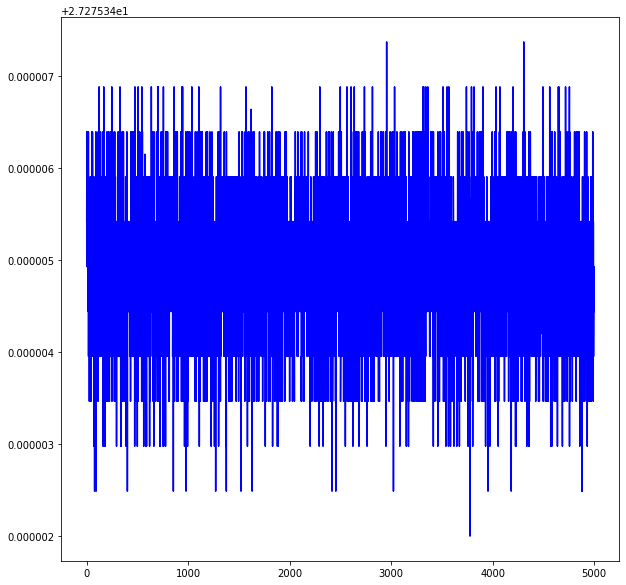

In [18]:
fig = plt.figure(figsize = (10, 10))
ax = fig.add_subplot(1, 1, 1)

plt.plot(fluxesWithoutJS * 1e-5, "b")

In [19]:
sim["PSF/MappedGaussian/IncludeJitterSmoothing"] = "yes"

outputWithJS = sim.run(removeOutputFile = True)

outputFile = h5py.File(workDir + "JitterSmoothing.hdf5")
starIDsInImage0, row, col, Xmm, Ymm, flux = output.getStarCoordinates(0)

In [20]:
print("Start")
phot.photometry(workDir + "JitterSmoothing.hdf5", "photometryOutputWithJS.hdf5", starIDsInImage0, maxNexposures=numExposures)
print("Done")

Start
0 5000
Looping over all images in HDF5 file.
Image # 0
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
Number of targets:  1
[1]
[1]
Image # 1
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
Number of targets:  1
[1]
[1]
Image # 2
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
Number of targets:  1
[1]
[1]
Image # 3
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
Number of targets:  1
[1]
[1]
Image # 4
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.0250250

Number of targets:  1
[1]
[1]
Image # 45
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
Number of targets:  1
[1]
[1]
Image # 46
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
Number of targets:  1
[1]
[1]
Image # 47
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
Number of targets:  1
[1]
[1]
Image # 48
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
Number of targets:  1
[1]
[1]
Image # 49
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU


Number of targets:  1
[1]
[1]
Image # 88
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
Number of targets:  1
[1]
[1]
Image # 89
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
Number of targets:  1
[1]
[1]
Image # 90
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
Number of targets:  1
[1]
[1]
Image # 91
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
Number of targets:  1
[1]
[1]
Image # 92
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU


Number of targets:  1
[1]
[1]
Image # 139
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
Number of targets:  1
[1]
[1]
Image # 140
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
Number of targets:  1
[1]
[1]
Image # 141
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
Number of targets:  1
[1]
[1]
Image # 142
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
Number of targets:  1
[1]
[1]
Image # 143
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-

Number of targets:  1
[1]
[1]
Image # 181
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
Number of targets:  1
[1]
[1]
Image # 182
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
Number of targets:  1
[1]
[1]
Image # 183
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
Number of targets:  1
[1]
[1]
Image # 184
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
Number of targets:  1
[1]
[1]
Image # 185
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-

...

Image # 4786
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
Number of targets:  1
[1]
[1]
Image # 4787
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
Number of targets:  1
[1]
[1]
Image # 4788
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
Number of targets:  1
[1]
[1]
Image # 4789
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
Number of targets:  1
[1]
[1]
Image # 4790
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
Number of targets:  

Number of targets:  1
[1]
[1]
Image # 4833
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
Number of targets:  1
[1]
[1]
Image # 4834
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
Number of targets:  1
[1]
[1]
Image # 4835
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
Number of targets:  1
[1]
[1]
Image # 4836
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
Number of targets:  1
[1]
[1]
Image # 4837
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.0250250250250

Number of targets:  1
[1]
[1]
Image # 4878
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
Number of targets:  1
[1]
[1]
Image # 4879
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
Number of targets:  1
[1]
[1]
Image # 4880
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
Number of targets:  1
[1]
[1]
Image # 4881
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
Number of targets:  1
[1]
[1]
Image # 4882
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.0250250250250

Number of targets:  1
[1]
[1]
Image # 4927
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
Number of targets:  1
[1]
[1]
Image # 4928
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
Number of targets:  1
[1]
[1]
Image # 4929
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
Number of targets:  1
[1]
[1]
Image # 4930
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
Number of targets:  1
[1]
[1]
Image # 4931
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.0250250250250

Number of targets:  1
[1]
[1]
Image # 4978
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
Number of targets:  1
[1]
[1]
Image # 4979
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
Number of targets:  1
[1]
[1]
Image # 4980
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
Number of targets:  1
[1]
[1]
Image # 4981
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.025025025025023 e-/ADU
Number of targets:  1
[1]
[1]
Image # 4982
    Subtracted bias level of 0.0 ADU
    Corrected for open-shutter smearing
    Converted from [ADU] to [electrons] using a Gain of 25.0250250250250

In [21]:
photFile = h5py.File("photometryOutputWithJS.hdf5")

In [22]:
fluxesWithJS = np.array([])

for exposure in range(numExposures):
    
    name = "/Photometry/Exposure{:06d}/estimatedFlux".format(exposure)
    flux = np.array(photFile[name])
    fluxesWithJS = np.append(fluxesWithJS, flux)

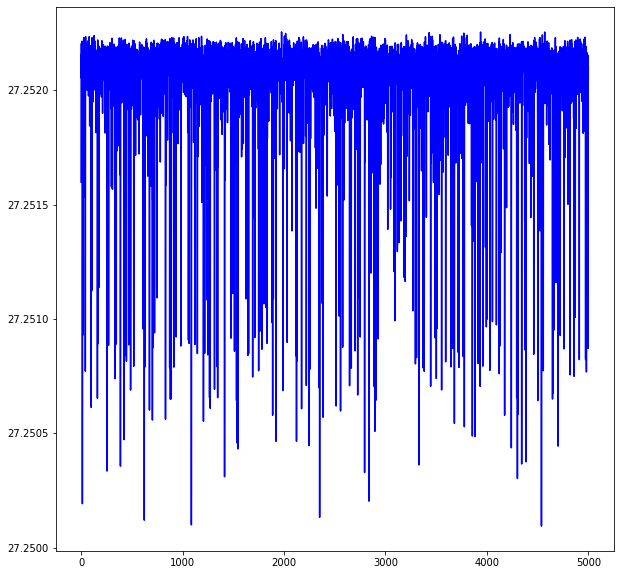

In [23]:
fig = plt.figure(figsize = (10, 10))
ax = fig.add_subplot(1, 1, 1)

plt.plot(fluxesWithJS * 1e-5, "b")

(0, 500)

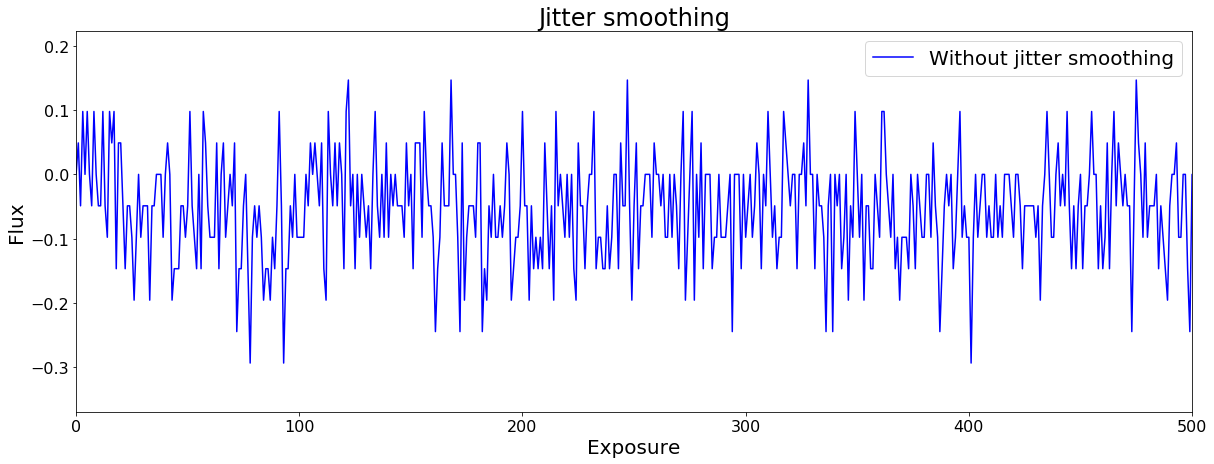

In [46]:
fig = plt.figure(figsize = (20, 7))
ax = fig.add_subplot(1, 1, 1)



###############
# From PlatoSim
###############

plt.plot(fluxesWithoutJS - fluxesWithoutJS[0], "b", label="Without jitter smoothing")
# plt.plot(fluxesWithJS, "r", label="With jitter smoothing")



########
# Layout
########

plt.title("Jitter smoothing", fontsize = 24)
plt.xlabel("Exposure", fontsize = 20)
plt.ylabel("Flux", fontsize = 20)

plt.legend(loc='best', fontsize = 20)

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
plt.xlim([0,500])

(0, 100)

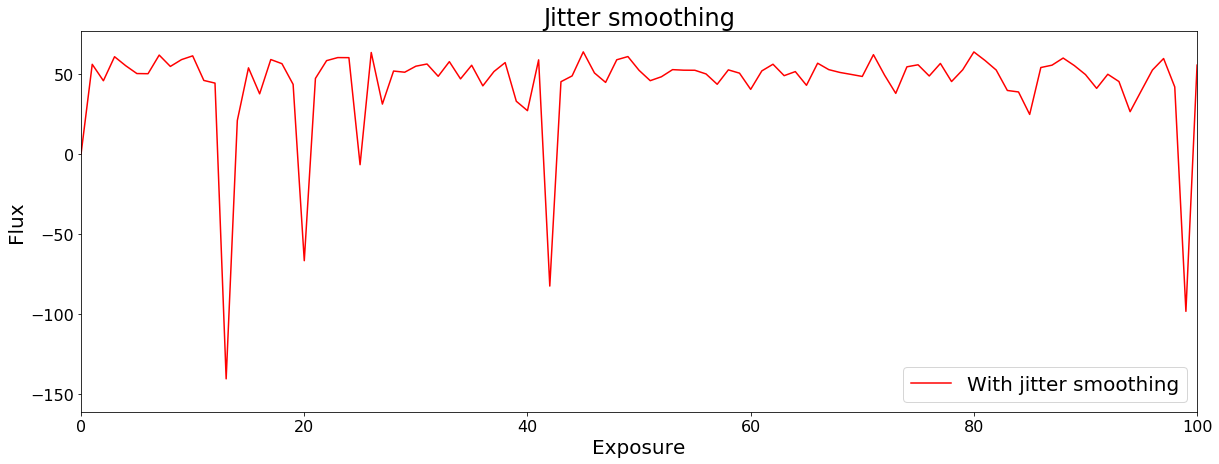

In [45]:
fig = plt.figure(figsize = (20, 7))
ax = fig.add_subplot(1, 1, 1)



###############
# From PlatoSim
###############

# plt.plot(fluxesWithoutJS - fluxesWithoutJS[0], "b", label="Without jitter smoothing")
plt.plot(fluxesWithJS - fluxesWithJS[0], "r", label="With jitter smoothing")



########
# Layout
########

plt.title("Jitter smoothing", fontsize = 24)
plt.xlabel("Exposure", fontsize = 20)
plt.ylabel("Flux", fontsize = 20)

plt.legend(loc='best', fontsize = 20)

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
plt.xlim([0,100])